In [1]:
import pandas as pd
from pyprojroot import here
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(here() / "data" / "raw" / "dados_macro.csv")
df_ans = pd.read_parquet(here() / "data" / "raw" / "dados_ans.parquet")

In [ ]:
#visualização inicial dos dados
df.info()

print(df.head(5))

print(df.isnull().sum())

print(len(df))

#verificação do indice em que o valor faltante aparece
indices_num = df.index[df.iloc[:, 2:].isnull().max(axis=1)]

print(list(indices_num))

df.drop(indices_num, inplace=True)

print(df.iloc[ 60:  , :])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         61 non-null     object 
 1   selic                        61 non-null     float64
 2   ipca                         61 non-null     float64
 3   inadimplencia_pf             61 non-null     float64
 4   juros_cartao                 61 non-null     float64
 5   massa_rendimento             61 non-null     float64
 6   desemprego                   61 non-null     float64
 7   indice_confianca_consumidor  61 non-null     float64
dtypes: float64(7), object(1)
memory usage: 3.9+ KB
      Date  selic  ipca  inadimplencia_pf  juros_cartao  massa_rendimento  \
0  2021-01   2.00  0.25              2.88         22.90        39518510.0   
1  2021-02   2.00  0.86              2.92         22.46        39916360.0   
2  2021-03   2.75  0.93            

In [ ]:
#dados descritivos de cada um dos dados macro
df.describe()

,selic,ipca,inadimplencia_pf,juros_cartao,massa_rendimento,desemprego,indice_confianca_consumidor
count,61.000000,61.000000,61.000000,61.000000,6.100000e+01,61.000000,61.000000
mean,11.303279,0.476557,3.749672,28.100984,4.502086e+07,8.729508,118.440164
std,3.692367,0.408521,0.572922,3.786618,2.718850e+06,2.819122,9.513484
min,2.000000,-0.680000,2.870000,21.030000,3.951851e+07,5.100000,103.600000
25%,10.500000,0.240000,3.480000,25.350000,4.287197e+07,6.600000,110.980000
50%,12.750000,0.440000,3.720000,29.080000,4.523551e+07,7.900000,116.790000
75%,13.750000,0.710000,4.040000,31.020000,4.735015e+07,10.500000,126.460000
max,15.000000,1.620000,5.050000,34.320000,4.909784e+07,14.900000,138.220000


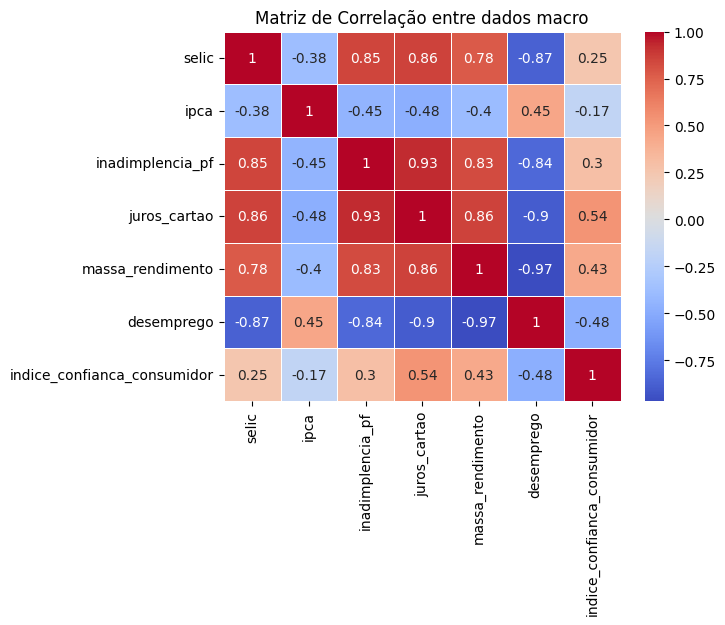

In [ ]:
num_cols = df.select_dtypes(include='number').columns

df_corr = df[num_cols].corr()

#correlação entre os dados macro, visão geral
sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação entre dados macro")
plt.show()

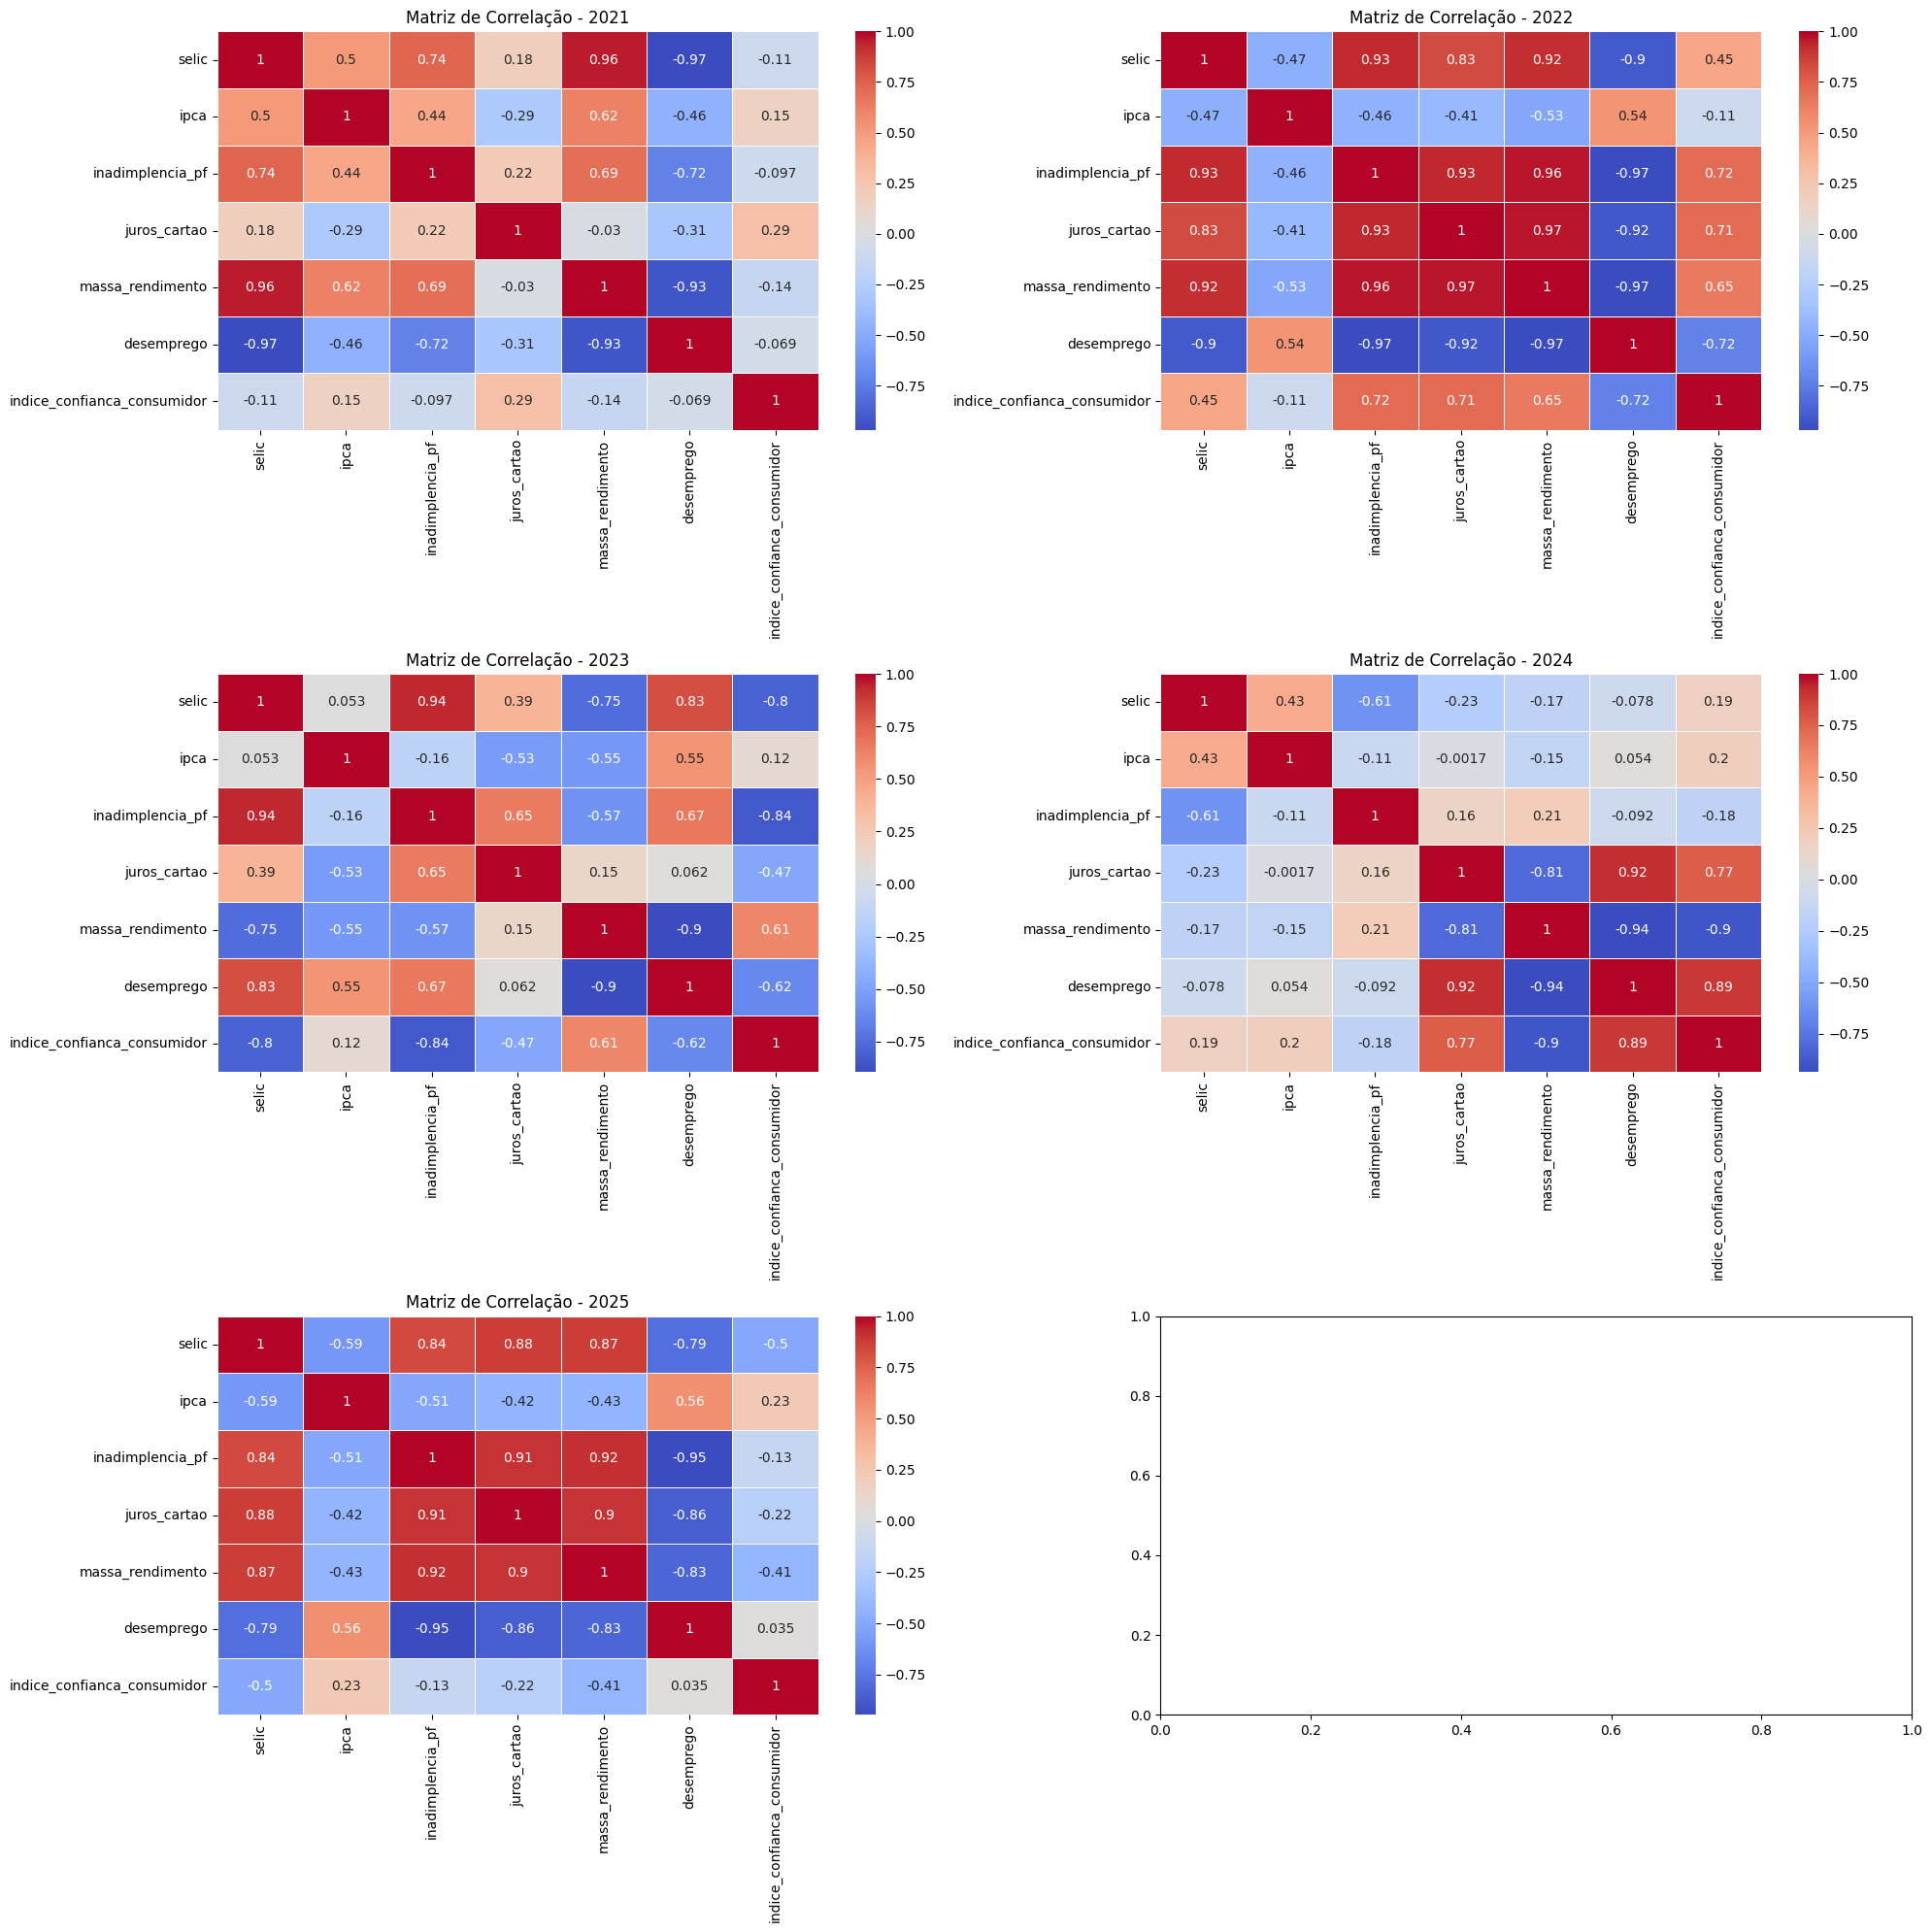

In [59]:
#visualização da correlação entre os dados macro a cada ano, para verificar se há alguma tendência ao longo do tempo
df['ano'] = df['Date'].str[:4]

anos = ['2021', '2022', '2023', '2024', '2025']

fig, axes = plt.subplots(3, 2, figsize=(20, 20))

axes = axes.flatten()


for i, ano in enumerate(anos):
    dados_ano = df[df['ano'] == ano]

    corr_anos = dados_ano.select_dtypes(include='number').corr() 

    sns.heatmap(corr_anos, annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[i])

    axes[i].set_title(f"Matriz de Correlação - {ano}")

plt.tight_layout()
plt.show()


In [ ]:
#visualização inicial dos dados ANS
df_ans.info()

df_ans.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14948836 entries, 0 to 14948835
Data columns (total 13 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   ano                       Int64 
 1   mes                       Int64 
 2   codigo_operadora          object
 3   sigla_uf                  object
 4   sexo                      object
 5   faixa_etaria              object
 6   tipo_vigencia_plano       object
 7   contratacao_beneficiario  object
 8   segmentacao_beneficiario  object
 9   tipo_vinculo              object
 10  total_ativos              Int64 
 11  total_adesoes             Int64 
 12  total_cancelados          Int64 
dtypes: Int64(5), object(8)
memory usage: 1.5+ GB


,ano,mes,total_ativos,total_adesoes,total_cancelados
count,14948836.0,14948836.0,14948836.0,14948836.0,14948836.0
mean,2022.715855,6.17878,236.75337,7.041659,6.437985
std,1.31332,3.423341,2083.662366,80.862196,76.24242
min,2021.0,1.0,0.0,0.0,0.0
25%,2022.0,3.0,2.0,0.0,0.0
50%,2023.0,6.0,11.0,0.0,0.0
75%,2024.0,9.0,60.0,1.0,1.0
max,2025.0,12.0,124250.0,16514.0,27127.0


In [66]:
df_ans = df_ans.sort_values(by='ano')

df_ans.head(5)

,ano,mes,codigo_operadora,sigla_uf,sexo,faixa_etaria,tipo_vigencia_plano,contratacao_beneficiario,segmentacao_beneficiario,tipo_vinculo,total_ativos,total_adesoes,total_cancelados
3518322,2021,5,311294,SP,F,16 a 20 anos,A,Coletivo Por Adesao,Ambulatorial + Hospitalar Com Obstetricia,Titular,13,0,1
3518321,2021,10,340120,SP,M,16 a 20 anos,P,Coletivo Por Adesao,Odontologico,Titular,5,0,0
3518320,2021,8,312851,SP,M,16 a 20 anos,P,Coletivo Empresarial,Ambulatorial + Hospitalar Com Obstetricia,Titular,12,0,0
3518350,2021,9,381144,SP,M,16 a 20 anos,P,Coletivo Empresarial,Odontologico,Dependente,34,1,0
3518349,2021,7,314315,SP,F,16 a 20 anos,P,Coletivo Empresarial,Odontologico,Titular,38,6,0
